## Imports

In [12]:
import torch
%env PYTORCH_ENABLE_MPS_FALLBACK=1
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from Utils.SVM_utils import train_svm, test_svm
from Utils.OfficeCaltechDecafLoader import OfficeCaltechDecafDataset
import sklearn
from ot_utils import *
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter, MappingTransport
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

env: PYTORCH_ENABLE_MPS_FALLBACK=1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Dataset

In [6]:
dataset = OfficeCaltechDecafDataset(data_path='/Users/balazsmorvay/PycharmProjects/fmri_classifier/Data/Office-Caltech')
X = dataset.X
y = dataset.y
m = dataset.m
domains = dataset.domains
domain_names = dataset.domain_names

In [7]:
X_all = []
y_all = []
for i, domain in enumerate(domains):
    domain_indices = np.where(m == domain)
    X_all.append(torch.tensor(X[domain_indices], dtype=torch.float32, device=device))
    y_all.append(torch.tensor(y[domain_indices], dtype=torch.int, device=device))

In [8]:
X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(X_all)):
    X_i = X_all[i].cpu()
    y_i = y_all[i].cpu()
    X_i_train, X_i_test, y_i_train, y_i_test = sklearn.model_selection.train_test_split(X_i, y_i, train_size=0.3, shuffle=True, stratify=y_i, random_state=42)
    X_trains.append(X_i_train.to(device))
    X_tests.append(X_i_test.to(device))
    y_trains.append(y_i_train.to('cpu'))
    y_tests.append(y_i_test.to('cpu'))

## Barycenter

In [11]:
n_train = 0
for i in range(len(X_trains)):
    n_train += X_trains[i].shape[0]
a1, a2, a3, a4 = ot.unif(len(X_trains[0])), ot.unif(len(X_trains[1])), ot.unif(len(X_trains[2])), ot.unif(len(X_trains[3]))
weights = [torch.tensor(a1, dtype=torch.float32, device=device), torch.tensor(a2, dtype=torch.float32, device=device), torch.tensor(a3, dtype=torch.float32, device=device), torch.tensor(a4, dtype=torch.float32, device=device)]
recompute = True

bary_labels = torch.concatenate(y_trains)
idx = torch.randperm(bary_labels.shape[0])
t = bary_labels[idx].view(bary_labels.size())

barycenter = free_support_sinkhorn_barycenter(
        measures_locations=X_trains,
        measures_weights=weights,
        measure_labels=y_trains,
        bary_labels=torch.concatenate(y_trains),
        reg=1e-1,
        numItermax=10,
        numInnerItermax=3000,
        verbose=True,
        X_init=torch.rand(size=(n_train, 4096), device=device),
        b=torch.ones(size=(n_train,), device=device) / n_train,
        method='sinkhorn_log',
        stopThr=0.0001
    )

iteration %d, displacement_square_norm=%f
 0 tensor(32548476., device='mps:0')
iteration %d, displacement_square_norm=%f
 1 tensor(825965.3750, device='mps:0')
iteration %d, displacement_square_norm=%f
 2 tensor(143526.2812, device='mps:0')
iteration %d, displacement_square_norm=%f
 3 tensor(13479.6670, device='mps:0')
iteration %d, displacement_square_norm=%f
 4 tensor(0.9101, device='mps:0')
iteration %d, displacement_square_norm=%f
 5 tensor(0.9101, device='mps:0')
iteration %d, displacement_square_norm=%f
 6 tensor(0.9101, device='mps:0')
iteration %d, displacement_square_norm=%f
 7 tensor(0.9101, device='mps:0')
iteration %d, displacement_square_norm=%f
 8 tensor(0.9101, device='mps:0')
iteration %d, displacement_square_norm=%f
 9 tensor(0.9101, device='mps:0')


## SVM training

In [17]:
for x_train in X_trains:
    x_train = x_train.to('cpu')

for y_train in y_trains:
    y_train = y_train.to('cpu')

data_svm = train_svm(X=torch.concatenate(X_trains).cpu(), y=torch.concatenate(y_trains).cpu(), kernel='rbf', C=1.0)
data_svm.fit_status_ == 0

[LibSVM]*.*
optimization finished, #iter = 157
obj = -16.029763, rho = 0.247762
nSV = 97, nBSV = 8
*.*
optimization finished, #iter = 162
obj = -17.614497, rho = 0.327415
nSV = 100, nBSV = 7
*.*
optimization finished, #iter = 173
obj = -29.271879, rho = 0.468748
nSV = 116, nBSV = 13
*
optimization finished, #iter = 150
obj = -19.287615, rho = 0.475994
nSV = 96, nBSV = 8
*
optimization finished, #iter = 159
obj = -20.670022, rho = 0.082779
nSV = 103, nBSV = 8
*
optimization finished, #iter = 150
obj = -24.169651, rho = 0.022107
nSV = 103, nBSV = 14
*.*
optimization finished, #iter = 166
obj = -27.063745, rho = 0.047463
nSV = 108, nBSV = 8
*.*
optimization finished, #iter = 161
obj = -22.311817, rho = 0.258399
nSV = 100, nBSV = 7
*.*
optimization finished, #iter = 172
obj = -23.142304, rho = 0.107381
nSV = 106, nBSV = 4
*.*
optimization finished, #iter = 159
obj = -14.272541, rho = 0.004201
nSV = 90, nBSV = 1
*.*
optimization finished, #iter = 166
obj = -18.845476, rho = 0.044310
nSV = 1

True

In [18]:
bary_svm = train_svm(barycenter.cpu(), bary_labels.cpu(), kernel='rbf', C=1.0)
bary_svm.fit_status_ == 0

[LibSVM]*
optimization finished, #iter = 94
obj = -3.268756, rho = 0.207011
nSV = 48, nBSV = 0
*
optimization finished, #iter = 92
obj = -3.666035, rho = 0.251310
nSV = 50, nBSV = 0
*
optimization finished, #iter = 111
obj = -6.487956, rho = 0.196569
nSV = 53, nBSV = 0
*
optimization finished, #iter = 91
obj = -3.371736, rho = 0.249840
nSV = 46, nBSV = 0
*
optimization finished, #iter = 89
obj = -4.453777, rho = 0.244112
nSV = 46, nBSV = 0
*
optimization finished, #iter = 98
obj = -4.754911, rho = 0.062919
nSV = 44, nBSV = 0
*
optimization finished, #iter = 99
obj = -5.557875, rho = 0.100057
nSV = 46, nBSV = 0
*
optimization finished, #iter = 97
obj = -4.124599, rho = 0.076023
nSV = 47, nBSV = 0
*
optimization finished, #iter = 111
obj = -5.346734, rho = 0.151867
nSV = 50, nBSV = 0
*
optimization finished, #iter = 89
obj = -3.436385, rho = 0.012184
nSV = 44, nBSV = 0
*
optimization finished, #iter = 108
obj = -3.886534, rho = -0.066620
nSV = 51, nBSV = 0
*
optimization finished, #iter 

True

{'accuracy': 0.9710144927536232, 'recall': array([1.        , 1.        , 0.86363636, 1.        , 0.89473684,
       1.        , 1.        , 0.95238095, 1.        , 1.        ]), 'precision': array([0.95238095, 1.        , 0.9047619 , 1.        , 0.85      ,
       1.        , 1.        , 1.        , 1.        , 1.        ]), 'fscore': array([0.97560976, 1.        , 0.88372093, 1.        , 0.87179487,
       1.        , 1.        , 0.97560976, 1.        , 1.        ])}


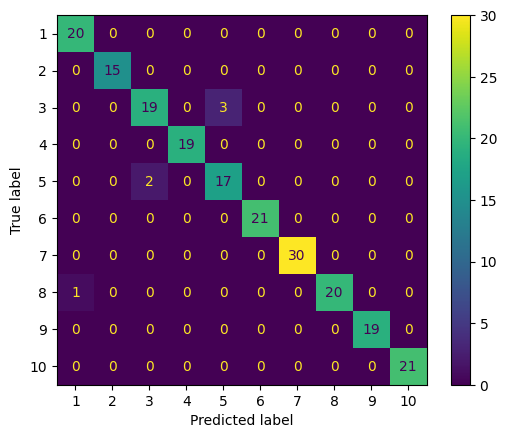

In [19]:
metrics, disp = test_svm(data_svm, X_tests[0].cpu(), y_tests[0].cpu())
disp.plot()
print(metrics)

{'accuracy': 0.9468599033816425, 'recall': array([1.        , 1.        , 0.90909091, 1.        , 0.89473684,
       1.        , 0.9       , 0.85714286, 1.        , 0.95238095]), 'precision': array([1.        , 1.        , 0.90909091, 0.79166667, 0.89473684,
       0.91304348, 1.        , 1.        , 1.        , 1.        ]), 'fscore': array([1.        , 1.        , 0.90909091, 0.88372093, 0.89473684,
       0.95454545, 0.94736842, 0.92307692, 1.        , 0.97560976])}


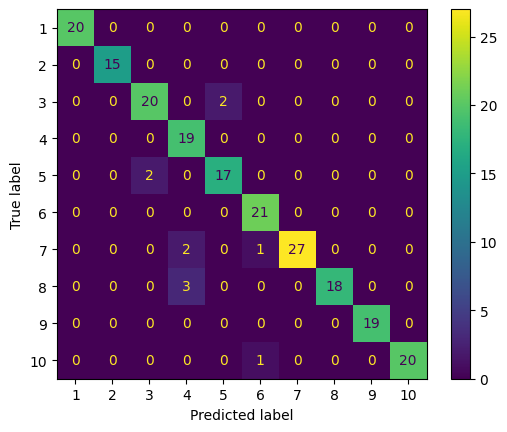

In [20]:
metrics, disp = test_svm(bary_svm, X_tests[0].cpu(), y_tests[0].cpu())
disp.plot()
print(metrics)

out of sample mapping
{'accuracy': 0.9565217391304348, 'recall': array([1.        , 1.        , 0.95454545, 1.        , 0.84210526,
       1.        , 0.96666667, 0.85714286, 1.        , 0.95238095]), 'precision': array([1.        , 1.        , 0.875     , 0.9047619 , 0.88888889,
       0.95454545, 1.        , 1.        , 1.        , 0.95238095]), 'fscore': array([1.        , 1.        , 0.91304348, 0.95      , 0.86486486,
       0.97674419, 0.98305085, 0.92307692, 1.        , 0.95238095])}


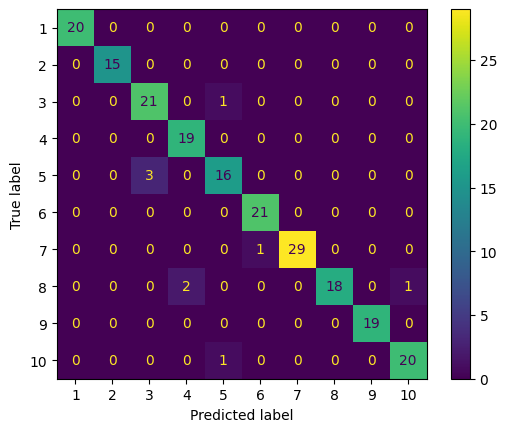

In [23]:
xs = X_trains[0]
xt = barycenter
ys = y_trains[0]
yt = bary_labels
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=1e-1, M=M, method='sinkhorn_log', numItermax=1000)

xst = barycentric_mapping(xs.cpu(), xt.cpu(), X_tests[0].cpu(), P.cpu())

metrics, disp = test_svm(bary_svm, xst.cpu(), y_tests[0].cpu())
disp.plot()
print(metrics)